# Draft

In [1]:
import webdataset as wds
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from src.segmentation.constants import PATH_SEG_DATA
from src.segmentation.models.dev.data_module import SegmentationDataModule, SegmentationDataModule2, get_path_shards

/home/jaffolabi/Documents/lung_map/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 1
%aimport src.segmentation.models.dev.data_module

In [9]:
shards_dir = 'shards_bcss'
data_module = SegmentationDataModule(
        train_urls=get_path_shards('train-full', shards_dir),
        val_urls=get_path_shards('val', shards_dir),
        test_urls=get_path_shards('test', shards_dir),
        n_images=122,
        batch_size=4, 
        num_workers=0,
        patches_per_image_train=5,
)

In [10]:
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()
test_loader = data_module.test_dataloader()

In [19]:
images, masks = next(iter(train_loader))

=== VÉRIFICATION DES TENSEURS ===
Images batch shape : torch.Size([4, 9, 224, 224]) (Attendu : [Batch, 9, H, W])
Images dtype       : torch.float32 (Attendu : torch.float32)
Valeurs Images     : Min=-2.12, Max=2.64

Masks batch shape  : torch.Size([4, 224, 224]) (Attendu : [Batch, H, W])
Masks dtype        : torch.int64 (Attendu : torch.int64 ou torch.long)
Classes présentes  : [0, 1, 2, 3]


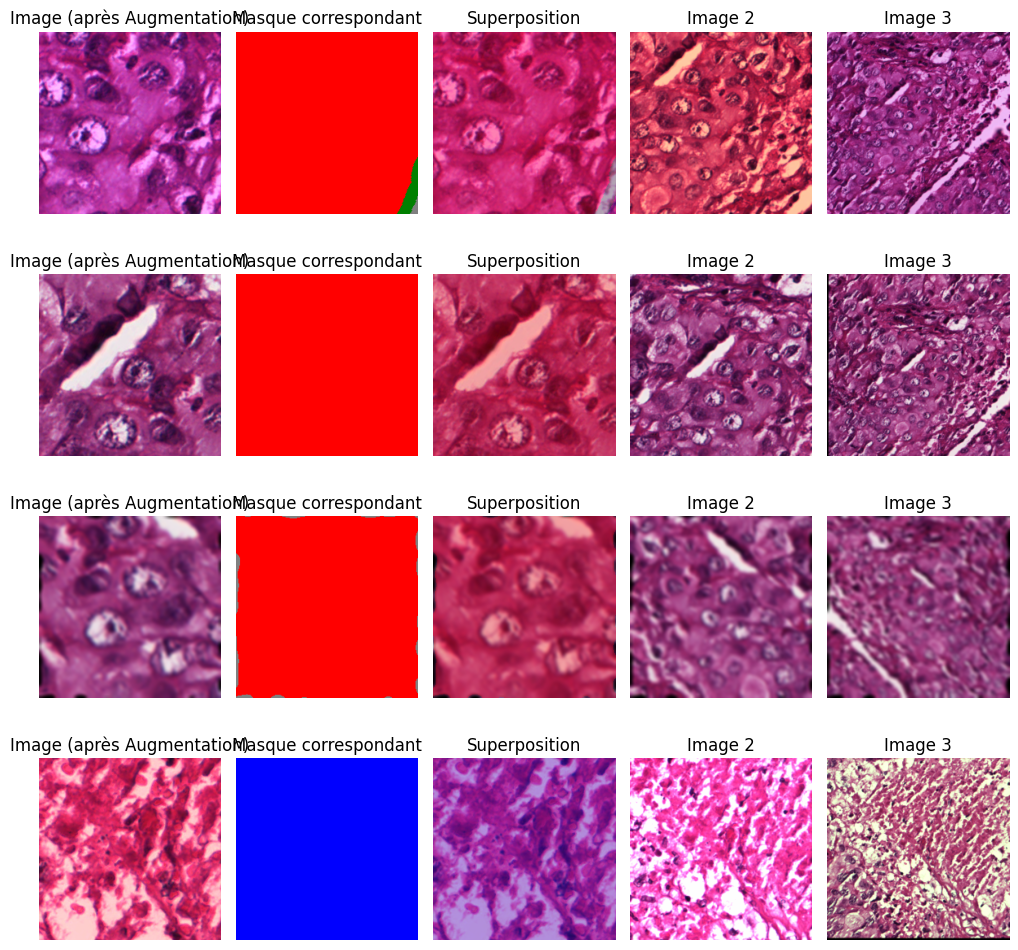

In [20]:
class_dict = {
    0: ("other", "gray"),
    1: ("tumeur", "red"),      
    2: ("necrosis", "blue"), 
    3: ("stroma", "green"),
}

# Extraction des couleurs pour créer la Colormap fixe
colors = [class_dict[i][1] for i in sorted(class_dict.keys())]
custom_cmap = ListedColormap(colors)

# Valeurs min et max pour forcer l'alignement des couleurs
vmin = 0
vmax = len(class_dict) - 1

print("=== VÉRIFICATION DES TENSEURS ===")
print(f"Images batch shape : {images.shape} (Attendu : [Batch, 9, H, W])")
print(f"Images dtype       : {images.dtype} (Attendu : torch.float32)")
print(f"Valeurs Images     : Min={images.min():.2f}, Max={images.max():.2f}\n")

print(f"Masks batch shape  : {masks.shape} (Attendu : [Batch, H, W])")
print(f"Masks dtype        : {masks.dtype} (Attendu : torch.int64 ou torch.long)")
print(f"Classes présentes  : {torch.unique(masks).tolist()}")

nb_cols = 5
fig, axes = plt.subplots(len(images), nb_cols, figsize=(10, nb_cols*2))

def denormalize(img):
    if img.min() < 0:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        result = std * img + mean
        result = np.clip(result, 0, 1)
        return result
    else:
        return img

for i in range(len(images)):

    img_display = images[i].permute(1, 2, 0).numpy()
    mask_display = masks[i].numpy()

    img1 = denormalize(img_display[:, :, :3])
    img2 = denormalize(img_display[:, :, 3:6])
    img3 = denormalize(img_display[:, :, 6:])

    # "Dé-normaliser" si normalisation avec les poids de imagenet
    """ if images.min() < 0:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1) """


    axes[i, 0].set_title("Image (après Augmentation)")
    axes[i, 0].imshow(img1)
    axes[i, 0].axis('off')

    axes[i, 1].set_title("Masque correspondant")
    axes[i, 1].imshow(mask_display, cmap=custom_cmap, vmin=vmin, vmax=vmax)
    axes[i, 1].axis('off')

    axes[i, 2].set_title("Superposition")
    axes[i, 2].imshow(img1)
    mask_overlay = np.ma.masked_where(mask_display == 0, mask_display)
    axes[i, 2].imshow(mask_overlay, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.3)
    axes[i, 2].axis('off')

    axes[i, 3].set_title("Image 2")
    axes[i, 3].imshow(img2)
    axes[i, 3].axis('off')

    axes[i, 4].set_title("Image 3")
    axes[i, 4].imshow(img3)
    axes[i, 4].axis('off')

plt.tight_layout()

In [7]:
# Check that R > B holds consistently now
for i, (images, masks) in enumerate(train_loader):
    for b in range(images.shape[0]):
        s1 = images[b][:3]
        r_mean = s1[0].mean().item()
        b_mean = s1[2].mean().item()
        if b_mean > r_mean:
            print(f"Sample {i} batch {b} : R={r_mean:.3f} B={b_mean:.3f} ← possible swap")
    if i > 20:
        break

Sample 0 batch 0 : R=0.682 B=0.695 ← possible swap
Sample 0 batch 3 : R=-0.978 B=-0.405 ← possible swap
Sample 1 batch 2 : R=0.485 B=0.744 ← possible swap
Sample 1 batch 3 : R=0.642 B=0.898 ← possible swap
Sample 2 batch 0 : R=0.571 B=0.694 ← possible swap
Sample 2 batch 1 : R=0.467 B=0.705 ← possible swap
Sample 2 batch 3 : R=0.451 B=0.596 ← possible swap
Sample 3 batch 0 : R=-0.035 B=0.399 ← possible swap
Sample 3 batch 2 : R=0.273 B=0.567 ← possible swap
Sample 3 batch 3 : R=-0.298 B=0.931 ← possible swap
Sample 4 batch 2 : R=0.966 B=1.280 ← possible swap
Sample 4 batch 3 : R=0.079 B=1.153 ← possible swap
Sample 5 batch 0 : R=1.048 B=1.371 ← possible swap
Sample 5 batch 1 : R=0.946 B=1.277 ← possible swap
Sample 5 batch 2 : R=1.140 B=1.484 ← possible swap
Sample 5 batch 3 : R=0.734 B=1.779 ← possible swap
Sample 6 batch 0 : R=0.720 B=1.802 ← possible swap
Sample 6 batch 1 : R=0.344 B=1.814 ← possible swap
Sample 6 batch 2 : R=1.510 B=1.796 ← possible swap
Sample 6 batch 3 : R=0.738 

In [31]:
img = images[0]
print("shape :", img.shape)
print("dtype :", img.dtype)
print("min   :", img.min().item())
print("max   :", img.max().item())
print("mean  :", img.mean().item())

shape : torch.Size([9, 224, 224])
dtype : torch.float32
min   : -2.1179039478302
max   : 2.4134204387664795
mean  : 0.6712191104888916


In [ ]:
def get_nb_elements(loader):
    sample_count = 0
    label_count = dict()
    for images, masks in loader:
        sample_count += len(images)
        for m in masks:
            labels, effs = np.unique(m, return_counts=True)
            for l, eff in zip(labels, effs):
                if l in label_count:
                    label_count[l] += eff
                else:
                    label_count[l] = eff

    return sample_count, label_count

train_stats = get_nb_elements(data_module.train_dataloader())
val_stats = get_nb_elements(data_module.val_dataloader())
test_stats = get_nb_elements(data_module.test_dataloader())

print(f'Train loader: {train_stats[0]} samples \n {train_stats[1]}')
print(f'Val loader: {val_stats[0]} samples \n {val_stats[1]}')
print(f'Test loader: {test_stats[0]} samples \n {test_stats[1]}')

/home/jaffolabi/Documents/lung_map/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train loader: 1649 samples 
 {np.int64(0): np.int64(6352305), np.int64(1): np.int64(32395093), np.int64(3): np.int64(38752679), np.int64(2): np.int64(5240147)}
Val loader: 405 samples 
 {np.int64(0): np.int64(1077554), np.int64(1): np.int64(9480531), np.int64(3): np.int64(8469748), np.int64(2): np.int64(1293447)}
Test loader: 524 samples 
 {np.int64(0): np.int64(1877413), np.int64(3): np.int64(14042750), np.int64(1): np.int64(9375249), np.int64(2): np.int64(996812)}


In [ ]:
def get_class_weight(loader, square_root=False):
    _, label_count = get_nb_elements(loader)
    total_pxl = np.sum(list(label_count.values()))
    freq = {int(label): count/total_pxl for label, count in label_count.items()}
    inv_feq = np.ones(len(freq))
    for label in freq:
        inv_feq[label] = 1/freq[label]
    if square_root:
        weights = np.sqrt(inv_feq) / np.sqrt(inv_feq).mean()
    else:
        weights = inv_feq / inv_feq.mean()
    return freq

In [16]:
from src.segmentation.models.dev.data_module import custom_decoder

In [17]:
test_dataset = wds.WebDataset(
                get_path_shards('test')
            ).decode(custom_decoder).to_tuple("__key__", "image.png", "mask.png")

/home/jaffolabi/Documents/lung_map/.venv/lib/python3.12/site-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")
